# Hardware Test in Pynq-Z2 Board

In [1]:
from pathlib import Path
from typing import Tuple

import numpy as np

from axi_stream_driver import NeuralNetworkOverlay

## Data

In [2]:
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

print("\nDataset shapes:")
print(f"  Test:  {X_test.shape}, labels: {y_test.shape}")


Dataset shapes:
  Test:  (120001, 8, 8, 1), labels: (120001,)


In [3]:
NUM_CLASSES = 3

## Neural Network

In [4]:
BATCH = 10 # Must be less than 20480 bits per DMA transfer

In [5]:
# Instantiate overlay for single or batch inference (8x8x1 in, 3 out)
nn = NeuralNetworkOverlay(
    "system.bit",
    x_shape=(BATCH, X_test.shape[1], X_test.shape[2], X_test.shape[3]),
    y_shape=(BATCH,     NUM_CLASSES),
)

# Run inference on the full test set in one call
y_hw, dts, rate = nn.predict(
    X_test, profile=True, debug=False,
)

PL inference: 100%|██████████| 12001/12001 [00:31<00:00, 385.32it/s]


Processed elements: 120001, Execution time: 15.0627 seconds, Performance rate: 7966.76 inferences/second


### Evaluate

In [6]:
# Compute predicted classes from raw logits
y_pred_hw = np.argmax(y_hw, axis=1)

accuracy = np.mean(y_pred_hw == y_test)
print(f"Hardware accuracy: {accuracy*100:.2f}%")
print(f"\nFirst 10 logits:\n{y_hw[:10]}")
print(f"\nFirst 10 predictions:   {y_pred_hw[:10]}")
print(f"First 10 ground truth:  {y_test[:10]}")

Hardware accuracy: 90.98%

First 10 logits:
[[ 1.609375   0.046875  -0.09375  ]
 [ 6.9453125 -6.609375   2.453125 ]
 [-3.375     -0.7109375  5.6875   ]
 [-1.9140625  4.125     -0.6640625]
 [-2.34375    1.375      1.0546875]
 [-3.453125   1.390625   2.84375  ]
 [-0.0390625  1.546875   0.4453125]
 [ 1.5625    -4.4609375  3.578125 ]
 [ 0.59375    2.8125    -0.0859375]
 [ 2.8203125 -4.4140625  2.90625  ]]

First 10 predictions:   [0 0 2 1 1 2 1 2 1 2]
First 10 ground truth:  [0 0 2 1 1 2 1 0 1 0]


## Save

In [7]:
np.save("y_hw.npy", y_hw)

# Inference Evaluation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    log_loss,
)

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

In [2]:
class_names = {"lateral_L": 0, "lateral_R": 1, "supine": 2}

y_test = np.load("input/y_test.npy")
y_hw = np.load("input/y_hw.npy")

y_hw_classes = np.argmax(y_hw, axis=1)
y_hw_proba = softmax(y_hw, axis=1)

loss = log_loss(y_true=y_hw_classes, y_pred=y_hw_proba)
accuracy = accuracy_score(y_test, y_hw_classes)

In [3]:
print("\nAccuracy Report for `PYNQ-Z2`:")
print("=" * 70)
print(f"  Loss: {loss * 100:.2f}%")
print(f"  Accuracy: {accuracy * 100:.2f}%")


Accuracy Report for `PYNQ-Z2`:
  Loss: 9.75%
  Accuracy: 90.98%


In [4]:
print("\nClassification Report for `PYNQ-Z2`:")
print("=" * 70)
print(
    classification_report(
        y_test,
        y_hw_classes,
        target_names=class_names,
        digits=4,
    )
)


Classification Report for `PYNQ-Z2`:
              precision    recall  f1-score   support

   lateral_L     0.9294    0.8850    0.9067     40000
   lateral_R     0.9005    0.9162    0.9083     40000
      supine     0.9007    0.9280    0.9141     40001

    accuracy                         0.9098    120001
   macro avg     0.9102    0.9098    0.9097    120001
weighted avg     0.9102    0.9098    0.9097    120001



Saved: figures/cm_pynq-z2.pdf


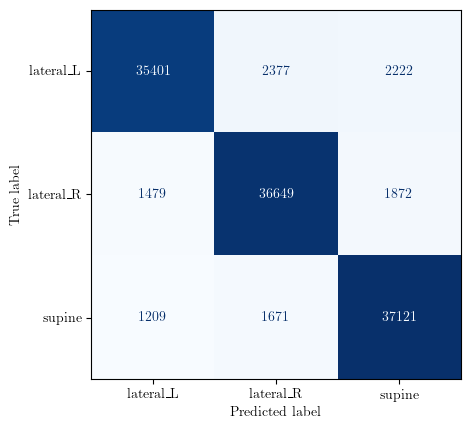

In [5]:
cm = confusion_matrix(y_test, y_hw_classes)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues", colorbar=False)
filepath = "figures/cm_pynq-z2.pdf"
plt.savefig(filepath, dpi=300, bbox_inches="tight", format="pdf")
print(f"Saved: {filepath}")
plt.show()